# Experiment 4 — spaCy vs BiLSTM-CRF on BC5CDR (Fair Comparison)

**Goal**: Direct, fair head-to-head comparison of two NER approaches on BC5CDR.

- **Model 1**: spaCy NER (CNN + hash embeddings, fine-tuned from `en_core_web_sm`)
- **Model 2**: BiLSTM-CRF with Word2Vec embeddings (trained from scratch)

**What makes this fair (unlike Exp 1 vs Exp 3):**
- Same random seed (42) for both models
- Same dataset splits (BC5CDR train/val/test)
- Same evaluation metric (`seqeval` F1) for both
- Same test set for final evaluation
- Checkpoints saved properly for both models

## 0. Install dependencies

In [2]:
!pip install spacy seqeval gensim torch scikit-learn matplotlib --quiet
!python -m spacy download en_core_web_sm --quiet
!pip install spacy-lookups-data --quiet

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 1. Config

In [3]:
import os

# ── Data paths ──────────────────────────────────────────────────
# Kaggle: '/kaggle/input/datasets/prajnagaur/bc5cdr-ntu'
# Colab:  '/content'
DATA_DIR = '/kaggle/input/datasets/prajnagaur/bc5cdr-ntu'

# ── Save dirs ───────────────────────────────────────────────────
SPACY_SAVE_DIR   = '/kaggle/working/models/exp4/spacy'
BILSTM_SAVE_DIR  = '/kaggle/working/models/exp4/bilstm'

os.makedirs(SPACY_SAVE_DIR,  exist_ok=True)
os.makedirs(BILSTM_SAVE_DIR, exist_ok=True)

# ── Shared hyperparams ──────────────────────────────────────────
SEED       = 42
MAX_EPOCHS = 20
PATIENCE   = 5
BATCH_SIZE = 32

# ── BiLSTM-specific ─────────────────────────────────────────────
EMBED_DIM  = 100
HIDDEN_DIM = 256
LR         = 1e-3

print('Config ready')
print(f'spaCy save  : {SPACY_SAVE_DIR}')
print(f'BiLSTM save : {BILSTM_SAVE_DIR}')

Config ready
spaCy save  : /kaggle/working/models/exp4/spacy
BiLSTM save : /kaggle/working/models/exp4/bilstm


## 2. Imports & seeds

In [4]:
import json, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import spacy
from spacy.tokens import DocBin
from spacy.training import Example

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from gensim.models import Word2Vec
from seqeval.metrics import classification_report, f1_score as seq_f1

# ── Set all seeds ────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('All seeds set to', SEED)

Device: cpu
All seeds set to 42


## 3. Shared data loading helpers

In [5]:
def load_jsonl(path):
    records = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def extract_tokens_labels(records):
    sentences, labels = [], []
    for rec in records:
        if 'tokens' in rec and 'ner_tags' in rec:
            toks, labs = rec['tokens'], rec['ner_tags']
        elif 'tokens' in rec and 'labels' in rec:
            toks, labs = rec['tokens'], rec['labels']
        elif 'words' in rec and 'tags' in rec:
            toks, labs = rec['words'], rec['tags']
        else:
            lists = [(k,v) for k,v in rec.items() if isinstance(v, list)]
            str_lists = [(k,v) for k,v in lists if v and isinstance(v[0], str)]
            if len(str_lists) >= 2:
                toks, labs = str_lists[0][1], str_lists[1][1]
            else:
                continue
        sentences.append(toks)
        labels.append(labs)
    return sentences, labels

def load_split(data_dir, split):
    path = Path(data_dir) / f'{split}.jsonl'
    return extract_tokens_labels(load_jsonl(str(path)))

def get_label_set(labels):
    unique = set(l for seq in labels for l in seq)
    return ['O'] + sorted(l for l in unique if l != 'O')

# ── Load BC5CDR ──────────────────────────────────────────────────
train_sents, train_labs = load_split(DATA_DIR, 'train')
val_sents,   val_labs   = load_split(DATA_DIR, 'validation')
test_sents,  test_labs  = load_split(DATA_DIR, 'test')

label_list = get_label_set(train_labs + val_labs)
entity_labels = [l for l in label_list if l != 'O']

print(f'Train : {len(train_sents)} sentences')
print(f'Val   : {len(val_sents)} sentences')
print(f'Test  : {len(test_sents)} sentences')
print(f'Labels: {label_list}')

Train : 5228 sentences
Val   : 5330 sentences
Test  : 5865 sentences
Labels: ['O', 'B-Chemical', 'B-Disease', 'I-Chemical', 'I-Disease']


---
# 🔵 MODEL 1 — spaCy NER

## 4. spaCy helpers

In [6]:
nlp_ref = spacy.load('en_core_web_sm')

def bio_to_spans(tokens, labels):
    text   = ' '.join(tokens)
    spans  = []
    offset = 0
    cur_start, cur_label = None, None
    for tok, lab in zip(tokens, labels):
        tok_end = offset + len(tok)
        if lab.startswith('B-'):
            if cur_label:
                spans.append((cur_start, offset - 1, cur_label))
            cur_start, cur_label = offset, lab[2:]
        elif lab.startswith('I-'):
            if cur_label is None:
                cur_start, cur_label = offset, lab[2:]
        else:
            if cur_label:
                spans.append((cur_start, offset - 1, cur_label))
                cur_start, cur_label = None, None
        offset = tok_end + 1
    if cur_label:
        spans.append((cur_start, offset - 1, cur_label))
    return text, spans

def build_docbin(sentences, labels):
    db, skipped = DocBin(), 0
    for toks, labs in zip(sentences, labels):
        text, spans = bio_to_spans(toks, labs)
        doc  = nlp_ref.make_doc(text)
        ents = []
        ok   = True
        for s, e, label in spans:
            span = doc.char_span(s, e, label=label, alignment_mode='expand')
            if span is None:
                ok = False; break
            ents.append(span)
        if not ok:
            skipped += 1; continue
        try:
            doc.ents = ents
        except Exception:
            skipped += 1; continue
        db.add(doc)
    if skipped:
        print(f'  Skipped {skipped} sentences')
    return db

def make_spacy_examples(sentences, labels, nlp_pipeline):
    db   = build_docbin(sentences, labels)
    docs = list(db.get_docs(nlp_ref.vocab))
    return [Example(nlp_pipeline.make_doc(d.text), d) for d in docs]

# seqeval-compatible extraction from spaCy examples
def spacy_examples_to_seqeval(examples, nlp_model):
    all_trues, all_preds = [], []
    for ex in examples:
        gold_doc = ex.reference
        pred_doc = nlp_model(gold_doc.text)
        gold_bio = ['O'] * len(gold_doc)
        for ent in gold_doc.ents:
            for i, tok in enumerate(gold_doc):
                if tok.idx == ent.start_char:
                    gold_bio[i] = f'B-{ent.label_}'
                elif ent.start_char < tok.idx < ent.end_char:
                    gold_bio[i] = f'I-{ent.label_}'
        pred_bio = ['O'] * len(pred_doc)
        for ent in pred_doc.ents:
            for i, tok in enumerate(pred_doc):
                if tok.idx == ent.start_char:
                    pred_bio[i] = f'B-{ent.label_}'
                elif ent.start_char < tok.idx < ent.end_char:
                    pred_bio[i] = f'I-{ent.label_}'
        n = min(len(gold_bio), len(pred_bio))
        all_trues.append(gold_bio[:n])
        all_preds.append(pred_bio[:n])
    return all_trues, all_preds

print('spaCy helpers ready')

spaCy helpers ready


## 5. Train spaCy

In [7]:
random.seed(SEED)

nlp_spacy = spacy.load('en_core_web_sm', exclude=['ner'])
ner = nlp_spacy.add_pipe('ner', last=True)
for lbl in entity_labels:
    ner.add_label(lbl)

spacy_train_examples = make_spacy_examples(train_sents, train_labs, nlp_spacy)
spacy_val_examples   = make_spacy_examples(val_sents,   val_labs,   nlp_spacy)

nlp_spacy.initialize(lambda: spacy_train_examples)
nlp_spacy.resume_training()

save_path = Path(SPACY_SAVE_DIR)
best_f1_spacy, bad_epochs = 0.0, 0
spacy_history = []

for epoch in range(1, MAX_EPOCHS + 1):
    random.shuffle(spacy_train_examples)
    losses  = {}
    batches = spacy.util.minibatch(spacy_train_examples, size=BATCH_SIZE)
    for batch in batches:
        nlp_spacy.update(batch, drop=0.3, losses=losses)

    # ── Evaluate with seqeval (same metric as BiLSTM) ────────────
    trues, preds = spacy_examples_to_seqeval(spacy_val_examples, nlp_spacy)
    f1 = seq_f1(trues, preds)

    print(f'Epoch {epoch:3d} | loss: {losses.get("ner",0):.1f} | val seqeval F1: {f1:.4f}')
    spacy_history.append({'epoch': epoch, 'loss': losses.get('ner', 0), 'val_f1': f1})

    if f1 > best_f1_spacy:
        best_f1_spacy, bad_epochs = f1, 0
        # ── CHECKPOINT SAVED ────────────────────────────────────
        nlp_spacy.to_disk(save_path / 'model-best')
        print(f'  ✓ Checkpoint saved — best val F1: {f1:.4f}')
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}')
            break

print(f'\nspaCy training done. Best val F1: {best_f1_spacy:.4f}')
print(f'Checkpoint at: {save_path / "model-best"}')

/usr/local/lib/python3.12/dist-packages/spacy/pipeline/attributeruler.py:137: UserWarning: [W036] The component 'matcher' does not have any patterns defined.
  matches = self.matcher(doc, allow_missing=True, as_spans=False)
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


Epoch   1 | loss: 17349.4 | val seqeval F1: 0.5807
  ✓ Checkpoint saved — best val F1: 0.5807
Epoch   2 | loss: 7083.3 | val seqeval F1: 0.6461
  ✓ Checkpoint saved — best val F1: 0.6461
Epoch   3 | loss: 4993.7 | val seqeval F1: 0.6834
  ✓ Checkpoint saved — best val F1: 0.6834
Epoch   4 | loss: 3903.2 | val seqeval F1: 0.6883
  ✓ Checkpoint saved — best val F1: 0.6883
Epoch   5 | loss: 3187.5 | val seqeval F1: 0.6954
  ✓ Checkpoint saved — best val F1: 0.6954
Epoch   6 | loss: 2834.0 | val seqeval F1: 0.6999
  ✓ Checkpoint saved — best val F1: 0.6999
Epoch   7 | loss: 2361.9 | val seqeval F1: 0.7035
  ✓ Checkpoint saved — best val F1: 0.7035
Epoch   8 | loss: 2165.9 | val seqeval F1: 0.7022
Epoch   9 | loss: 1980.5 | val seqeval F1: 0.7066
  ✓ Checkpoint saved — best val F1: 0.7066
Epoch  10 | loss: 1772.6 | val seqeval F1: 0.7098
  ✓ Checkpoint saved — best val F1: 0.7098
Epoch  11 | loss: 1650.9 | val seqeval F1: 0.7066
Epoch  12 | loss: 1509.6 | val seqeval F1: 0.7066
Epoch  13 | 

## 6. Evaluate spaCy on test set

In [9]:
# Load best checkpoint
nlp_spacy_best = spacy.load(Path(SPACY_SAVE_DIR) / 'model-best')
spacy_test_examples = make_spacy_examples(test_sents, test_labs, nlp_spacy_best)

spacy_test_trues, spacy_test_preds = spacy_examples_to_seqeval(spacy_test_examples, nlp_spacy_best)
spacy_test_f1     = seq_f1(spacy_test_trues, spacy_test_preds)
spacy_test_report = classification_report(spacy_test_trues, spacy_test_preds, output_dict=True)

print('=== spaCy — Test Results ===')
print(f'Test F1       : {spacy_test_f1:.4f}')
wa = spacy_test_report.get('weighted avg', {})
print(f'Test Precision: {float(wa.get("precision",0)):.4f}')
print(f'Test Recall   : {float(wa.get("recall",0)):.4f}')
print(classification_report(spacy_test_trues, spacy_test_preds))

from pathlib import Path
import json

save_path = Path(SPACY_SAVE_DIR) / "test_report.json"

with open(save_path, "w") as f:
    json.dump(spacy_test_report, f, indent=2, default=int)

=== spaCy — Test Results ===
Test F1       : 0.6999
Test Precision: 0.8173
Test Recall   : 0.6098
              precision    recall  f1-score   support

    Chemical       0.84      0.72      0.77      5385
     Disease       0.79      0.47      0.59      4424

   micro avg       0.82      0.61      0.70      9809
   macro avg       0.82      0.60      0.68      9809
weighted avg       0.82      0.61      0.69      9809



---
# 🟢 MODEL 2 — BiLSTM-CRF + Word2Vec

## 7. Word2Vec embeddings

In [10]:
random.seed(SEED)
np.random.seed(SEED)

all_sents = train_sents + val_sents
w2v = Word2Vec(
    sentences=all_sents,
    vector_size=EMBED_DIM,
    window=5,
    min_count=1,
    workers=4,
    epochs=10,
    sg=1,
    seed=SEED
)

word2idx = {'<PAD>': 0, '<UNK>': 1}
for sent in all_sents:
    for tok in sent:
        w = tok.lower()
        if w not in word2idx:
            word2idx[w] = len(word2idx)

embed_matrix = np.random.uniform(-0.1, 0.1, (len(word2idx), EMBED_DIM))
embed_matrix[0] = 0
for w, idx in word2idx.items():
    if w in w2v.wv:
        embed_matrix[idx] = w2v.wv[w]

label2idx = {l: i for i, l in enumerate(label_list)}
idx2label = {i: l for l, i in label2idx.items()}

print(f'Vocab size     : {len(word2idx)}')
print(f'Embedding shape: {embed_matrix.shape}')
print(f'Labels         : {label_list}')

Vocab size     : 12072
Embedding shape: (12072, 100)
Labels         : ['O', 'B-Chemical', 'B-Disease', 'I-Chemical', 'I-Disease']


## 8. BiLSTM-CRF model definition

In [11]:
class CRF(nn.Module):
    def __init__(self, num_tags):
        super().__init__()
        self.num_tags          = num_tags
        self.transitions       = nn.Parameter(torch.randn(num_tags, num_tags))
        self.start_transitions = nn.Parameter(torch.randn(num_tags))
        self.end_transitions   = nn.Parameter(torch.randn(num_tags))

    def _log_sum_exp(self, tensor, dim):
        max_val, _ = tensor.max(dim)
        return max_val + (tensor - max_val.unsqueeze(dim)).exp().sum(dim).log()

    def _forward_alg(self, emissions, mask):
        seq_len, batch_size, _ = emissions.shape
        score = self.start_transitions + emissions[0]
        for i in range(1, seq_len):
            m  = mask[i].unsqueeze(-1)
            bc = score.unsqueeze(2) + self.transitions
            new_score = self._log_sum_exp(bc + emissions[i].unsqueeze(1), 1)
            score = torch.where(m.bool(), new_score, score)
        return self._log_sum_exp(score + self.end_transitions, 1)

    def _score_sentence(self, emissions, tags, mask):
        seq_len = emissions.shape[0]
        score   = self.start_transitions[tags[0]] + emissions[0].gather(1, tags[0].unsqueeze(1)).squeeze(1)
        for i in range(1, seq_len):
            score += (self.transitions[tags[i], tags[i-1]] +
                      emissions[i].gather(1, tags[i].unsqueeze(1)).squeeze(1)) * mask[i]
        last_idx  = mask.long().sum(0) - 1
        last_tags = tags.gather(0, last_idx.unsqueeze(0)).squeeze(0)
        return score + self.end_transitions[last_tags]

    def neg_log_likelihood(self, emissions, tags, mask):
        e = emissions.transpose(0, 1)
        m = mask.transpose(0, 1).float()
        t = tags.transpose(0, 1)
        return (self._forward_alg(e, m) - self._score_sentence(e, t, m)).mean()

    def decode(self, emissions, mask):
        e = emissions.transpose(0, 1)
        m = mask.transpose(0, 1).float()
        seq_len, batch_size, _ = e.shape
        viterbi = self.start_transitions + e[0]
        backptr = []
        for i in range(1, seq_len):
            bc = viterbi.unsqueeze(2) + self.transitions
            best_scores, best_tags = bc.max(1)
            viterbi = torch.where(m[i].unsqueeze(-1).bool(), best_scores + e[i], viterbi)
            backptr.append(best_tags)
        viterbi += self.end_transitions
        best_last  = viterbi.argmax(1)
        best_paths = [best_last.tolist()]
        for bp in reversed(backptr):
            best_paths.append(bp.gather(1, torch.tensor(best_paths[-1]).unsqueeze(1).to(bp.device)).squeeze(1).tolist())
        best_paths.reverse()
        result = []
        for b in range(batch_size):
            length = int(m[:, b].sum())
            result.append([best_paths[i][b] for i in range(length)])
        return result


class BiLSTMCRF(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_tags, weights=None, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if weights is not None:
            self.embedding.weight = nn.Parameter(torch.tensor(weights, dtype=torch.float32))
        self.dropout = nn.Dropout(dropout)
        self.lstm    = nn.LSTM(embed_dim, hidden_dim // 2, batch_first=True,
                               bidirectional=True, num_layers=2, dropout=dropout)
        self.fc      = nn.Linear(hidden_dim, num_tags)
        self.crf     = CRF(num_tags)

    def _get_emissions(self, tokens, mask):
        x = self.dropout(self.embedding(tokens))
        lengths = mask.sum(1).cpu()
        packed  = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        out, _  = self.lstm(packed)
        out, _  = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.fc(self.dropout(out))

    def forward(self, tokens, labels, mask):
        emissions = self._get_emissions(tokens, mask)
        return self.crf.neg_log_likelihood(emissions, labels, mask)

    def predict(self, tokens, mask):
        emissions = self._get_emissions(tokens, mask)
        return self.crf.decode(emissions, mask)


print('BiLSTM-CRF model defined')

BiLSTM-CRF model defined


## 9. Dataset & DataLoader

In [12]:
class NERDataset(Dataset):
    def __init__(self, sentences, labels, max_len=128):
        self.data = []
        for toks, labs in zip(sentences, labels):
            toks = toks[:max_len]; labs = labs[:max_len]
            self.data.append((
                [word2idx.get(t.lower(), 1) for t in toks],
                [label2idx[l] for l in labs]
            ))
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate_fn(batch):
    token_seqs, label_seqs = zip(*batch)
    max_len = max(len(s) for s in token_seqs)
    tokens  = torch.zeros(len(batch), max_len, dtype=torch.long)
    labels  = torch.zeros(len(batch), max_len, dtype=torch.long)
    mask    = torch.zeros(len(batch), max_len, dtype=torch.bool)
    for i, (ts, ls) in enumerate(zip(token_seqs, label_seqs)):
        tokens[i, :len(ts)] = torch.tensor(ts)
        labels[i, :len(ls)] = torch.tensor(ls)
        mask[i,   :len(ts)] = True
    return tokens, labels, mask

def evaluate_bilstm(model, loader):
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for tokens, labels, mask in loader:
            tokens, labels, mask = tokens.to(device), labels.to(device), mask.to(device)
            for pred, lab, m in zip(model.predict(tokens, mask), labels, mask):
                n = m.sum().item()
                all_preds.append([idx2label[i] for i in pred[:n]])
                all_trues.append([idx2label[i] for i in lab[:n].tolist()])
    return seq_f1(all_trues, all_preds), classification_report(all_trues, all_preds, output_dict=True), all_preds, all_trues

train_dl = DataLoader(NERDataset(train_sents, train_labs), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_dl   = DataLoader(NERDataset(val_sents,   val_labs),   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_dl  = DataLoader(NERDataset(test_sents,  test_labs),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f'Train batches: {len(train_dl)} | Val: {len(val_dl)} | Test: {len(test_dl)}')

Train batches: 164 | Val: 167 | Test: 184


## 10. Train BiLSTM-CRF

In [13]:
torch.manual_seed(SEED)

bilstm_model = BiLSTMCRF(len(word2idx), EMBED_DIM, HIDDEN_DIM, len(label_list), embed_matrix).to(device)
optimizer    = optim.AdamW(bilstm_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler    = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

save_path_bilstm = Path(BILSTM_SAVE_DIR)
best_f1_bilstm   = 0.0
bad_epochs_b     = 0
bilstm_history   = []

for epoch in range(1, MAX_EPOCHS + 1):
    bilstm_model.train()
    total_loss = 0
    for tokens, labels, mask in train_dl:
        tokens, labels, mask = tokens.to(device), labels.to(device), mask.to(device)
        optimizer.zero_grad()
        loss = bilstm_model(tokens, labels, mask)
        loss.backward()
        nn.utils.clip_grad_norm_(bilstm_model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()

    val_f1, _, _, _ = evaluate_bilstm(bilstm_model, val_dl)
    scheduler.step(1 - val_f1)
    avg_loss = total_loss / len(train_dl)
    print(f'Epoch {epoch:3d} | loss: {avg_loss:.4f} | val seqeval F1: {val_f1:.4f}')
    bilstm_history.append({'epoch': epoch, 'loss': avg_loss, 'val_f1': val_f1})

    if val_f1 > best_f1_bilstm:
        best_f1_bilstm, bad_epochs_b = val_f1, 0
        # ── CHECKPOINT SAVED ────────────────────────────────────
        torch.save(bilstm_model.state_dict(), save_path_bilstm / 'best_model.pt')
        json.dump(word2idx,  open(save_path_bilstm / 'word2idx.json',  'w'))
        json.dump(label2idx, open(save_path_bilstm / 'label2idx.json', 'w'))
        print(f'  ✓ Checkpoint saved — best val F1: {val_f1:.4f}')
    else:
        bad_epochs_b += 1
        if bad_epochs_b >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}')
            break

print(f'\nBiLSTM-CRF training done. Best val F1: {best_f1_bilstm:.4f}')
print(f'Checkpoint at: {save_path_bilstm / "best_model.pt"}')

Epoch   1 | loss: 8.7153 | val seqeval F1: 0.5480
  ✓ Checkpoint saved — best val F1: 0.5480
Epoch   2 | loss: 2.7069 | val seqeval F1: 0.6727
  ✓ Checkpoint saved — best val F1: 0.6727
Epoch   3 | loss: 1.1408 | val seqeval F1: 0.7117
  ✓ Checkpoint saved — best val F1: 0.7117
Epoch   4 | loss: 0.1777 | val seqeval F1: 0.7294
  ✓ Checkpoint saved — best val F1: 0.7294
Epoch   5 | loss: -0.5268 | val seqeval F1: 0.7430
  ✓ Checkpoint saved — best val F1: 0.7430
Epoch   6 | loss: -1.2023 | val seqeval F1: 0.7422
Epoch   7 | loss: -1.7195 | val seqeval F1: 0.7375
Epoch   8 | loss: -2.2439 | val seqeval F1: 0.7494
  ✓ Checkpoint saved — best val F1: 0.7494
Epoch   9 | loss: -2.7516 | val seqeval F1: 0.7462
Epoch  10 | loss: -3.2063 | val seqeval F1: 0.7528
  ✓ Checkpoint saved — best val F1: 0.7528
Epoch  11 | loss: -3.6781 | val seqeval F1: 0.7503
Epoch  12 | loss: -4.1566 | val seqeval F1: 0.7467
Epoch  13 | loss: -4.5449 | val seqeval F1: 0.7468
Epoch  14 | loss: -4.9732 | val seqeval 

## 11. Evaluate BiLSTM-CRF on test set

In [14]:
bilstm_model.load_state_dict(torch.load(save_path_bilstm / 'best_model.pt'))
bilstm_test_f1, bilstm_test_report, bilstm_test_preds, bilstm_test_trues = evaluate_bilstm(bilstm_model, test_dl)

print('=== BiLSTM-CRF — Test Results ===')
print(f'Test F1       : {bilstm_test_f1:.4f}')
wa = bilstm_test_report.get('weighted avg', {})
print(f'Test Precision: {float(wa.get("precision",0)):.4f}')
print(f'Test Recall   : {float(wa.get("recall",0)):.4f}')
print(classification_report(bilstm_test_trues, bilstm_test_preds))

import numpy as np
import json

def json_converter(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")

with open(save_path_bilstm / 'test_report.json', 'w') as f:
    json.dump(bilstm_test_report, f, indent=2, default=json_converter)

=== BiLSTM-CRF — Test Results ===
Test F1       : 0.7323
Test Precision: 0.8185
Test Recall   : 0.6748
              precision    recall  f1-score   support

    Chemical       0.91      0.65      0.76      5385
     Disease       0.70      0.70      0.70      4424

   micro avg       0.80      0.67      0.73      9809
   macro avg       0.81      0.68      0.73      9809
weighted avg       0.82      0.67      0.73      9809



---
# 📊 Comparison Plots

## Plot 1 — Val F1 curves side by side

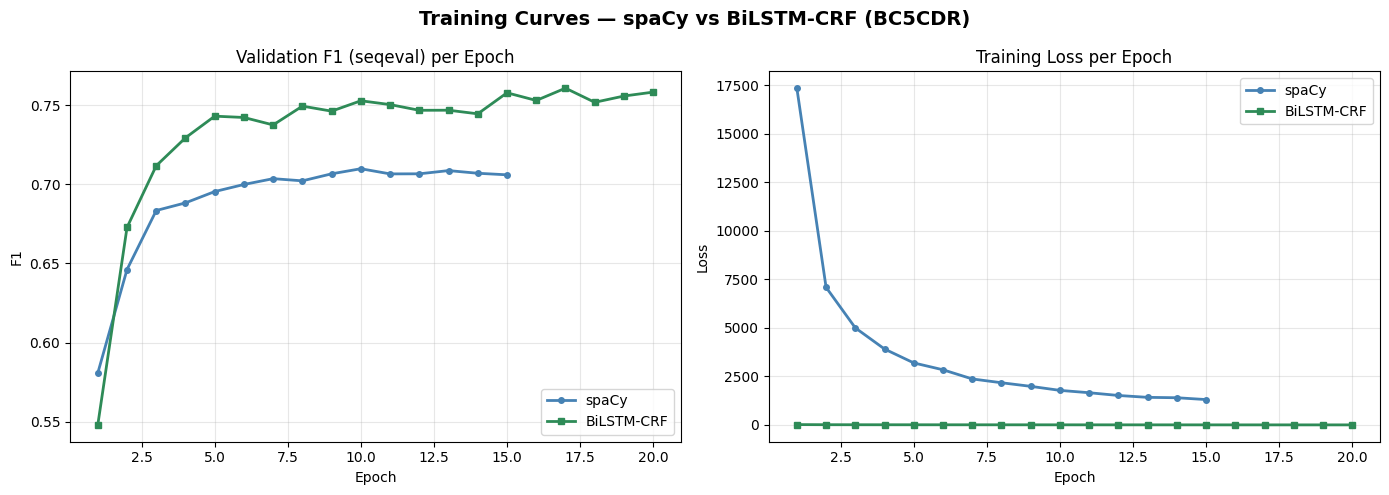

Saved: exp4_training_curves.png


In [15]:
e_sp = [h['epoch']  for h in spacy_history]
f_sp = [h['val_f1'] for h in spacy_history]
l_sp = [h['loss']   for h in spacy_history]

e_bi = [h['epoch']  for h in bilstm_history]
f_bi = [h['val_f1'] for h in bilstm_history]
l_bi = [h['loss']   for h in bilstm_history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — spaCy vs BiLSTM-CRF (BC5CDR)', fontsize=14, fontweight='bold')

# Val F1
axes[0].plot(e_sp, f_sp, color='steelblue',  linewidth=2, marker='o', markersize=4, label='spaCy')
axes[0].plot(e_bi, f_bi, color='seagreen',   linewidth=2, marker='s', markersize=4, label='BiLSTM-CRF')
axes[0].set_title('Validation F1 (seqeval) per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('F1')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(e_sp, l_sp, color='steelblue',  linewidth=2, marker='o', markersize=4, label='spaCy')
axes[1].plot(e_bi, l_bi, color='seagreen',   linewidth=2, marker='s', markersize=4, label='BiLSTM-CRF')
axes[1].set_title('Training Loss per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/exp4_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp4_training_curves.png')

## Plot 2 — Test P / R / F1 bar chart

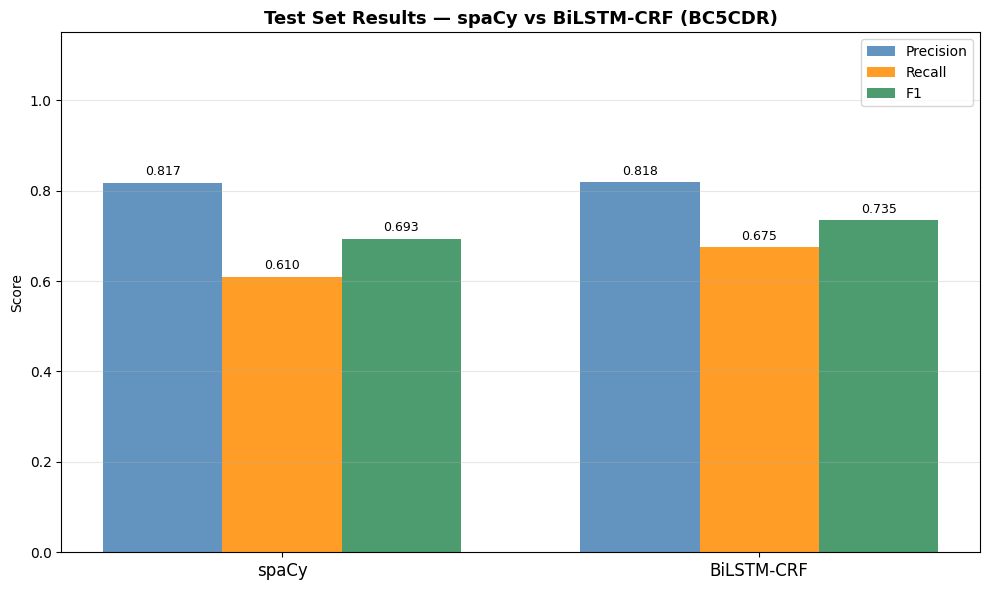

Saved: exp4_test_comparison.png


In [16]:
def get_prf(report):
    wa = report.get('weighted avg', {})
    return float(wa.get('precision',0)), float(wa.get('recall',0)), float(wa.get('f1-score',0))

sp_p, sp_r, sp_f = get_prf(spacy_test_report)
bi_p, bi_r, bi_f = get_prf(bilstm_test_report)

models = ['spaCy', 'BiLSTM-CRF']
precs  = [sp_p, bi_p]
recs   = [sp_r, bi_r]
f1s    = [sp_f, bi_f]

x = np.arange(len(models)); width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width, precs, width, label='Precision', color='steelblue',  alpha=0.85)
b2 = ax.bar(x,         recs,  width, label='Recall',    color='darkorange', alpha=0.85)
b3 = ax.bar(x + width, f1s,   width, label='F1',        color='seagreen',   alpha=0.85)
for bar in [*b1, *b2, *b3]:
    h = bar.get_height()
    if h > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)
ax.set_title('Test Set Results — spaCy vs BiLSTM-CRF (BC5CDR)', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.15)
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/exp4_test_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp4_test_comparison.png')

## Plot 3 — Per-entity F1 comparison (Chemical & Disease)

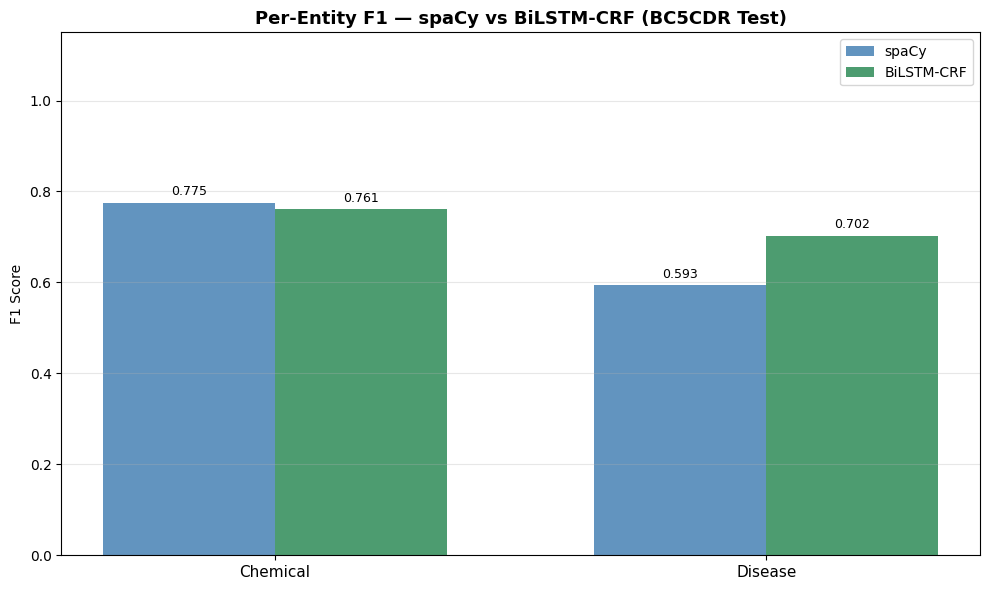

Saved: exp4_per_entity_f1.png


In [17]:
# Collect per-entity F1 for both models
def get_per_entity_f1(report):
    out = {}
    for key, val in report.items():
        if key in ('micro avg','macro avg','weighted avg','accuracy','O'): continue
        if isinstance(val, dict) and 'f1-score' in val:
            out[key] = {'p': float(val['precision']), 'r': float(val['recall']), 'f': float(val['f1-score'])}
    return out

sp_per  = get_per_entity_f1(spacy_test_report)
bi_per  = get_per_entity_f1(bilstm_test_report)
all_ents = sorted(set(list(sp_per.keys()) + list(bi_per.keys())))

sp_f1s = [sp_per.get(e, {}).get('f', 0) for e in all_ents]
bi_f1s = [bi_per.get(e, {}).get('f', 0) for e in all_ents]

x = np.arange(len(all_ents)); width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width/2, sp_f1s, width, label='spaCy',       color='steelblue', alpha=0.85)
b2 = ax.bar(x + width/2, bi_f1s, width, label='BiLSTM-CRF',  color='seagreen',  alpha=0.85)
for bar in [*b1, *b2]:
    h = bar.get_height()
    if h > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)
ax.set_title('Per-Entity F1 — spaCy vs BiLSTM-CRF (BC5CDR Test)', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(all_ents, fontsize=11)
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.15)
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/exp4_per_entity_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp4_per_entity_f1.png')

## Plot 4 — Confusion matrices (entity-only, no O)

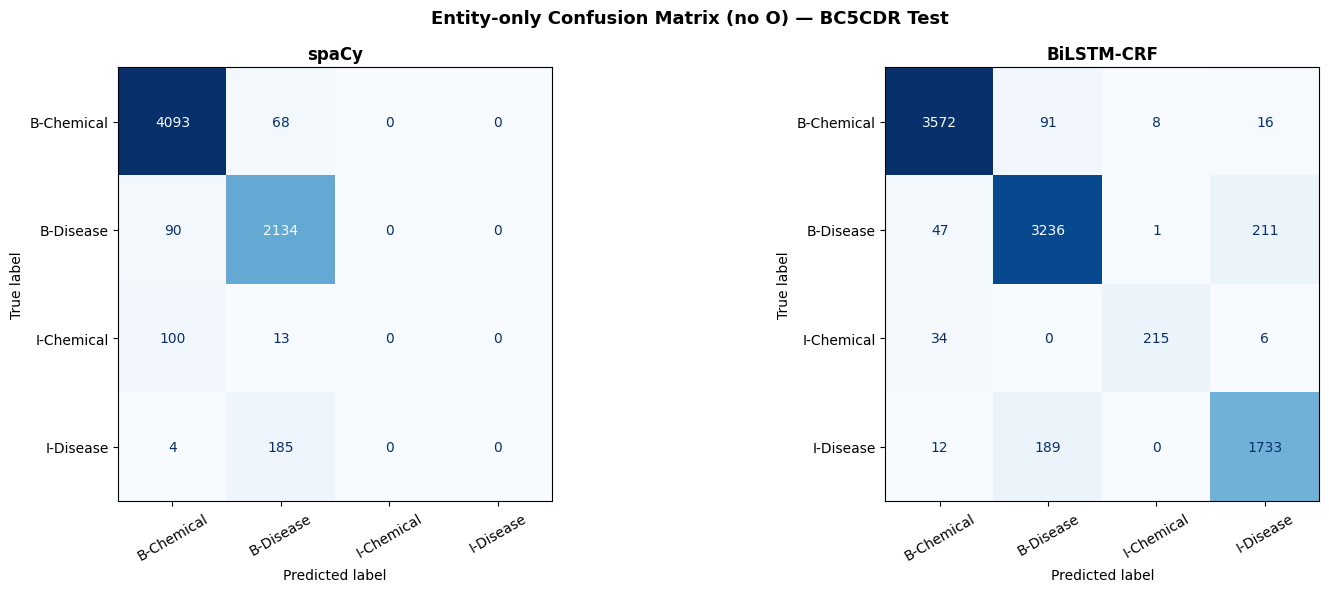

Saved: exp4_confusion_no_O.png


In [18]:
labels_no_O = [l for l in label_list if l != 'O']

def get_flat_no_O(trues, preds):
    flat_t = [t for seq in trues for t in seq if t != 'O']
    flat_p = [p for seq_t, seq_p in zip(trues, preds) for t, p in zip(seq_t, seq_p) if t != 'O']
    return flat_t, flat_p

sp_ft, sp_fp = get_flat_no_O(spacy_test_trues, spacy_test_preds)
bi_ft, bi_fp = get_flat_no_O(bilstm_test_trues, bilstm_test_preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Entity-only Confusion Matrix (no O) — BC5CDR Test', fontsize=13, fontweight='bold')

for ax, ft, fp, title in [(ax1, sp_ft, sp_fp, 'spaCy'), (ax2, bi_ft, bi_fp, 'BiLSTM-CRF')]:
    cm   = confusion_matrix(ft, fp, labels=labels_no_O)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_no_O)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/exp4_confusion_no_O.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp4_confusion_no_O.png')

## Plot 5 — Collapsed confusion matrices (B-/I- merged)

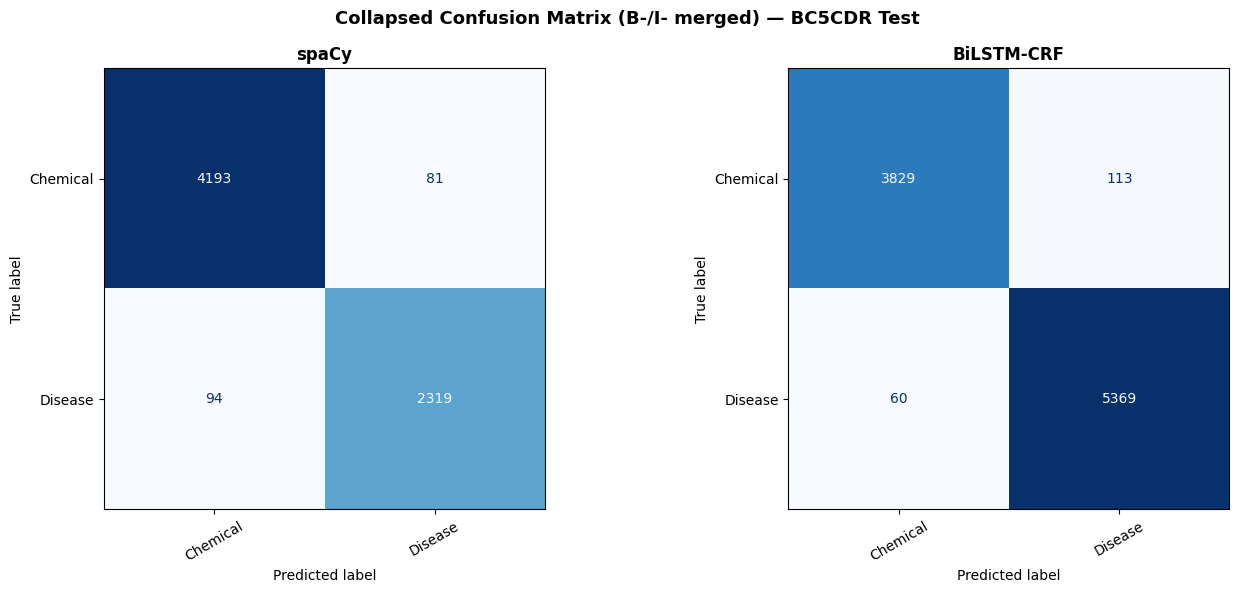

Saved: exp4_confusion_collapsed.png


In [19]:
def collapse(tag):
    return 'O' if tag == 'O' else tag.split('-')[-1]

def get_collapsed_flat(trues, preds):
    ct = [[collapse(t) for t in seq] for seq in trues]
    cp = [[collapse(p) for p in seq] for seq in preds]
    collapsed_labels = sorted(set(t for seq in ct for t in seq if t != 'O'))
    ft = [t for seq in ct for t in seq if t != 'O']
    fp = [p for seq_t, seq_p in zip(ct, cp) for t, p in zip(seq_t, seq_p) if t != 'O']
    return ft, fp, collapsed_labels

sp_ct, sp_cp, sp_cl = get_collapsed_flat(spacy_test_trues, spacy_test_preds)
bi_ct, bi_cp, bi_cl = get_collapsed_flat(bilstm_test_trues, bilstm_test_preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Collapsed Confusion Matrix (B-/I- merged) — BC5CDR Test', fontsize=13, fontweight='bold')

for ax, ft, fp, cl, title in [(ax1, sp_ct, sp_cp, sp_cl, 'spaCy'), (ax2, bi_ct, bi_cp, bi_cl, 'BiLSTM-CRF')]:
    cm   = confusion_matrix(ft, fp, labels=cl)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cl)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/exp4_confusion_collapsed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp4_confusion_collapsed.png')

## Plot 6 — Error examples: where one model fails and the other succeeds

In [20]:
print('=' * 80)
print('Examples where BiLSTM-CRF correct but spaCy wrong')
print('=' * 80)
shown = 0
for toks, true_seq, sp_seq, bi_seq in zip(test_sents, bilstm_test_trues, spacy_test_preds, bilstm_test_preds):
    n = min(len(true_seq), len(sp_seq), len(bi_seq))
    if true_seq[:n] != sp_seq[:n] and true_seq[:n] == bi_seq[:n]:
        print(f'\nExample {shown+1}')
        print(f'{"Token":<22} | {"Gold":<15} | {"spaCy":<15} | {"BiLSTM":<15}')
        print('-' * 72)
        for tok, tr, sp, bi in zip(toks[:n], true_seq[:n], sp_seq[:n], bi_seq[:n]):
            mark = ' ✗' if tr != sp else ''
            print(f'{tok:<22} | {tr:<15} | {sp:<15}{mark:<3} | {bi:<15}')
        shown += 1
        if shown >= 5: break
if shown == 0: print('None found.')

print('\n' + '=' * 80)
print('Examples where spaCy correct but BiLSTM-CRF wrong')
print('=' * 80)
shown = 0
for toks, true_seq, sp_seq, bi_seq in zip(test_sents, bilstm_test_trues, spacy_test_preds, bilstm_test_preds):
    n = min(len(true_seq), len(sp_seq), len(bi_seq))
    if true_seq[:n] == sp_seq[:n] and true_seq[:n] != bi_seq[:n]:
        print(f'\nExample {shown+1}')
        print(f'{"Token":<22} | {"Gold":<15} | {"spaCy":<15} | {"BiLSTM":<15}')
        print('-' * 72)
        for tok, tr, sp, bi in zip(toks[:n], true_seq[:n], sp_seq[:n], bi_seq[:n]):
            mark = ' ✗' if tr != bi else ''
            print(f'{tok:<22} | {tr:<15} | {sp:<15} | {bi:<15}{mark:<3}')
        shown += 1
        if shown >= 5: break
if shown == 0: print('None found.')

Examples where BiLSTM-CRF correct but spaCy wrong

Example 1
Token                  | Gold            | spaCy           | BiLSTM         
------------------------------------------------------------------------
Thus                   | O               | O                  | O              
,                      | O               | O                  | O              
indomethacin           | B-Chemical      | B-Chemical         | B-Chemical     
by                     | O               | O                  | O              
inhibition             | O               | O                  | O              
of                     | O               | O                  | O              
prostaglandin          | B-Chemical      | O               ✗  | B-Chemical     
synthesis              | O               | O                  | O              
may                    | O               | O                  | O              
diminish               | O               | O                  | O    

## Final summary table

In [21]:
print('\n' + '=' * 70)
print('EXPERIMENT 4 — FINAL RESULTS: spaCy vs BiLSTM-CRF on BC5CDR')
print('=' * 70)
print(f'Metric: seqeval F1 | Seed: {SEED} | Test split: BC5CDR official test')
print('-' * 70)
print(f'{"Model":<25} {"Precision":>12} {"Recall":>12} {"F1":>12}')
print('-' * 70)
print(f'{"spaCy":<25} {sp_p:>12.4f} {sp_r:>12.4f} {sp_f:>12.4f}')
print(f'{"BiLSTM-CRF + W2V":<25} {bi_p:>12.4f} {bi_r:>12.4f} {bi_f:>12.4f}')
print('-' * 70)
diff = bi_f - sp_f
direction = '↑ BiLSTM-CRF better' if diff > 0 else '↑ spaCy better'
print(f'\nF1 difference: {diff:+.4f} ({direction})')
print()
print('Per-entity breakdown:')
print(f'{"Entity":<25} {"spaCy F1":>12} {"BiLSTM F1":>12}')
print('-' * 50)
for ent in all_ents:
    sf = sp_per.get(ent, {}).get('f', 0)
    bf = bi_per.get(ent, {}).get('f', 0)
    print(f'{ent:<25} {sf:>12.4f} {bf:>12.4f}')
print('-' * 50)
print()
print('Checkpoints saved at:')
print(f'  spaCy   : {SPACY_SAVE_DIR}/model-best/')
print(f'  BiLSTM  : {BILSTM_SAVE_DIR}/best_model.pt')


EXPERIMENT 4 — FINAL RESULTS: spaCy vs BiLSTM-CRF on BC5CDR
Metric: seqeval F1 | Seed: 42 | Test split: BC5CDR official test
----------------------------------------------------------------------
Model                        Precision       Recall           F1
----------------------------------------------------------------------
spaCy                           0.8173       0.6098       0.6931
BiLSTM-CRF + W2V                0.8185       0.6748       0.7346
----------------------------------------------------------------------

F1 difference: +0.0415 (↑ BiLSTM-CRF better)

Per-entity breakdown:
Entity                        spaCy F1    BiLSTM F1
--------------------------------------------------
Chemical                        0.7749       0.7611
Disease                         0.5935       0.7023
--------------------------------------------------

Checkpoints saved at:
  spaCy   : /kaggle/working/models/exp4/spacy/model-best/
  BiLSTM  : /kaggle/working/models/exp4/bilstm/best_model.

In [22]:
import shutil
shutil.make_archive('/kaggle/working/exp4_spacy_ckpt', 'zip',
                    '/kaggle/working/models/exp4/spacy/model-best')
shutil.make_archive('/kaggle/working/exp4_bilstm_ckpt', 'zip',
                    '/kaggle/working/models/exp4/bilstm')
print('✅ done')

✅ done
